# Udemy Courses Dataset: Preprocessing

## 1. Notebook Goal

This notebook prepares a clean recommendation-ready version of the Udemy Courses dataset. The processed dataset will be used later by the TF-IDF and KNN recommenders, so the goal is to keep the transformation simple, transparent, and reproducible.

This preprocessing notebook continues from the findings in `01_data_understanding.ipynb`. The EDA identified duplicate course records, useful recommendation features, and text fields that need light cleaning, so this notebook focuses on duplicate handling, feature preparation, text cleaning, and recommendation-ready feature creation.


## 2. Import Libraries


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 3. Load Raw Dataset

The raw dataset is loaded from `data/raw/udemy_courses.csv`.

In [2]:
raw_data_path = Path("data/raw/udemy_courses.csv")
if not raw_data_path.exists():
    raw_data_path = Path("../data/raw/udemy_courses.csv")

df_raw = pd.read_csv(raw_data_path)
df_raw.head()


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


The raw dataset loads correctly and contains course metadata such as course titles, subjects, levels, prices, subscribers, reviews, and course duration. These fields are enough for a first version of a content-based recommender.


## 4. Select Recommendation Features

The recommender models do not need every column from the raw dataset. We keep the main course identifier, text/category fields, and numeric popularity or course-size indicators. Columns such as URL and publication timestamp are excluded because they are not required for the first recommender versions.

`is_paid` and `num_lectures` are also left out of this first preprocessing version. `price` already captures much of the free-versus-paid information from `is_paid`, while `num_lectures` is excluded for now to keep the initial recommendation pipeline simpler.


In [3]:
recommendation_columns = [
    "course_id",
    "course_title",
    "subject",
    "level",
    "num_subscribers",
    "num_reviews",
    "price",
    "content_duration",
]

df = df_raw[recommendation_columns].copy()
df.head()


,course_id,course_title,subject,level,num_subscribers,num_reviews,price,content_duration
0,1070968,Ultimate Investment Banking Course,Business Finance,All Levels,2147,23,200,1.5
1,1113822,Complete GST Course & Certification - Grow You...,Business Finance,All Levels,2792,923,75,39.0
2,1006314,Financial Modeling for Business Analysts and C...,Business Finance,Intermediate Level,2174,74,45,2.5
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,Business Finance,All Levels,2451,11,95,3.0
4,1011058,How To Maximize Your Profits Trading Options,Business Finance,Intermediate Level,1276,45,200,2.0


The selected dataset keeps the fields that are directly useful for recommendations. `course_id` is retained as a stable identifier, while `course_title`, `subject`, and `level` will become the main text input for the recommender models.


## 5. Initial Data Quality Snapshot

Before changing the data, we check missing values and duplicates. This gives us a clear before/after comparison for the preprocessing steps.


In [4]:
initial_quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_share": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})

print(f"Initial rows: {len(df):,}")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate course IDs: {df.duplicated(subset='course_id').sum():,}")
initial_quality


Initial rows: 3,678
Exact duplicate rows: 6
Duplicate course IDs: 6


,missing_values,missing_share,dtype
course_id,0,0.0,int64
course_title,0,0.0,object
subject,0,0.0,object
level,0,0.0,object
num_subscribers,0,0.0,int64
num_reviews,0,0.0,int64
price,0,0.0,int64
content_duration,0,0.0,float64


The selected columns do not contain missing values in the current raw file. However, the dataset has 6 exact duplicate rows and 6 duplicate course IDs, so duplicate removal is needed before modeling.


## 6. Basic Text Cleaning

The text cleaning is intentionally simple and explainable: lowercase text, remove basic punctuation, and normalize repeated spaces. Advanced NLP steps such as stemming and lemmatization are not used yet.

The cleaning keeps Unicode word characters so non-English course titles are not accidentally removed.


In [5]:
def clean_text(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower()
    value = re.sub(r"[^\w+.#\s]", " ", value, flags=re.UNICODE)
    value = re.sub(r"\s+", " ", value).strip()
    return value

text_columns = ["course_title", "subject", "level"]
for column in text_columns:
    df[column] = df[column].apply(clean_text)

df[text_columns].head()


,course_title,subject,level
0,ultimate investment banking course,business finance,all levels
1,complete gst course certification grow your ca...,business finance,all levels
2,financial modeling for business analysts and c...,business finance,intermediate level
3,beginner to pro financial analysis in excel 2017,business finance,all levels
4,how to maximize your profits trading options,business finance,intermediate level


After cleaning, text fields are lowercase and more consistent. This makes later similarity calculations easier because the same words will be represented in a more standardized way.


## 7. Handle Missing Values

The current dataset does not contain missing values, but the preprocessing notebook should still define a clear policy. Rows without a course ID or title are not useful for recommendations and are removed. Missing categorical values are labeled as `unknown`, while missing numeric values are replaced with `0` so KNN can later use numeric features without errors.


In [6]:
df = df.dropna(subset=["course_id", "course_title"]).copy()

categorical_columns = ["subject", "level"]
numeric_columns = ["num_subscribers", "num_reviews", "price", "content_duration"]

for column in categorical_columns:
    df[column] = df[column].fillna("unknown")
    df[column] = df[column].replace("", "unknown")

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce").fillna(0)

missing_after_handling = df.isna().sum()
missing_after_handling


course_id           0
course_title        0
subject             0
level               0
num_subscribers     0
num_reviews         0
price               0
content_duration    0
dtype: int64

No missing values remain after the handling step. Keeping this check in the notebook is useful because it protects the workflow if the raw dataset changes later.


## 8. Remove Duplicate Courses

Duplicate rows and duplicate course IDs can bias recommendations because the same course may appear more than once. We first remove exact duplicate rows, then keep the first record for any repeated `course_id`.


In [7]:
rows_before_deduplication = len(df)

df = df.drop_duplicates().copy()
df = df.drop_duplicates(subset="course_id", keep="first").copy()

rows_after_deduplication = len(df)
removed_rows = rows_before_deduplication - rows_after_deduplication

print(f"Rows before deduplication: {rows_before_deduplication:,}")
print(f"Rows after deduplication: {rows_after_deduplication:,}")
print(f"Rows removed: {removed_rows:,}")


Rows before deduplication: 3,678
Rows after deduplication: 3,672
Rows removed: 6


The preprocessing step removes 6 duplicate records. The final row count is still almost the same as the original dataset, so the cleaning improves data quality without significantly reducing the available course catalog.


## 9. Create Combined Features

The `combined_features` column joins the main text fields into one model-ready text representation. This column will be the primary input for the upcoming TF-IDF recommender. It can also support KNN experiments later after vectorization and feature transformation, especially when combined with numeric features.


In [8]:
df["combined_features"] = (
    df["course_title"].fillna("")
    + " "
    + df["subject"].fillna("")
    + " "
    + df["level"].fillna("")
)

df["combined_features"] = df["combined_features"].apply(clean_text)
df[["course_id", "course_title", "subject", "level", "combined_features"]].head()


,course_id,course_title,subject,level,combined_features
0,1070968,ultimate investment banking course,business finance,all levels,ultimate investment banking course business fi...
1,1113822,complete gst course certification grow your ca...,business finance,all levels,complete gst course certification grow your ca...
2,1006314,financial modeling for business analysts and c...,business finance,intermediate level,financial modeling for business analysts and c...
3,1210588,beginner to pro financial analysis in excel 2017,business finance,all levels,beginner to pro financial analysis in excel 20...
4,1011058,how to maximize your profits trading options,business finance,intermediate level,how to maximize your profits trading options b...


The combined text field now contains the course title, subject, and level in one column. This creates a simple and reusable text input for TF-IDF, while still allowing the KNN notebook to reuse it later after vectorization and transformation.


## 10. Combined Feature Length Check

For text-based recommendation, the length of `combined_features` matters. Very short rows may not contain enough information for similarity search, while extremely long rows can sometimes dominate text representations.


In [9]:
df["combined_word_count"] = df["combined_features"].str.split().str.len()
df["combined_char_count"] = df["combined_features"].str.len()

length_summary = df[["combined_word_count", "combined_char_count"]].describe().round(2)
short_combined_rows = df[df["combined_word_count"] <= 3][["course_id", "course_title", "subject", "level", "combined_features", "combined_word_count"]]
long_combined_rows = df[df["combined_word_count"] >= 20][["course_id", "course_title", "subject", "level", "combined_features", "combined_word_count"]]

print(f"Rows with very short combined features (<= 3 words): {len(short_combined_rows):,}")
print(f"Rows with long combined features (>= 20 words): {len(long_combined_rows):,}")
length_summary


Rows with very short combined features (<= 3 words): 0
Rows with long combined features (>= 20 words): 5


,combined_word_count,combined_char_count
count,3672.00,3672.00
mean,10.98,74.34
std,2.60,14.08
min,5.00,35.00
25%,9.00,65.00
50%,11.00,77.00
75%,13.00,84.00
max,50.00,268.00


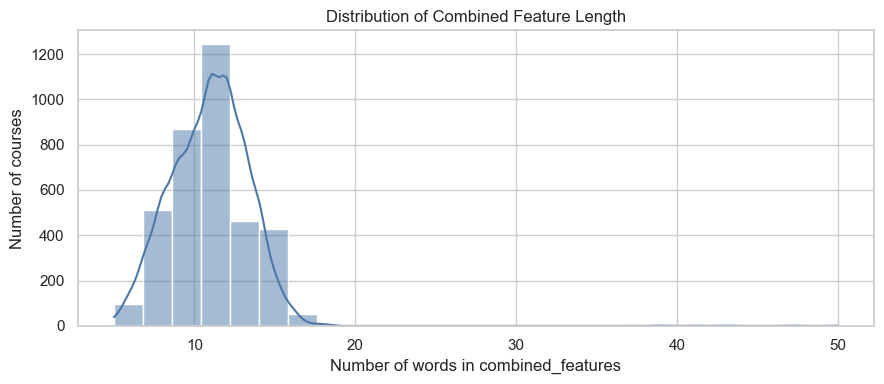

,course_id,course_title,subject,level,combined_features,combined_word_count
2186,286898,aprende a tocar el acordeón de oído y con técn...,musical instruments,all levels,aprende a tocar el acordeón de oído y con técn...,50
1875,149716,learn to play fernando sor s study in b minor ...,musical instruments,all levels,learn to play fernando sor s study in b minor ...,47
2169,151027,introduction to guitar a course for beginners ...,musical instruments,all levels,introduction to guitar a course for beginners ...,43
2036,1052180,how to play electric guitar https www.udemy.co...,musical instruments,all levels,how to play electric guitar https www.udemy.co...,41
291,52118,multiply your returns using value investing ht...,business finance,all levels,multiply your returns using value investing ht...,39


In [10]:
plt.figure(figsize=(9, 4))
sns.histplot(df["combined_word_count"], bins=25, kde=True, color="#4C78A8")
plt.title("Distribution of Combined Feature Length")
plt.xlabel("Number of words in combined_features")
plt.ylabel("Number of courses")
plt.tight_layout()
plt.show()

long_combined_rows.sort_values("combined_word_count", ascending=False).head()


The combined text looks usable for the first recommender version. There are no extremely short rows, so every course has at least some text signal from title, subject, and level. Only a few rows are much longer than the rest, so they are worth noticing but not worth removing at this stage.


## 11. Consistency Checks

These checks confirm that the processed dataset is ready for recommender modeling. We check for empty combined text, remaining duplicates, negative numeric values, and suspicious zero values in important numeric fields.


In [11]:
consistency_checks = pd.Series({
    "rows": len(df),
    "empty_combined_features": df["combined_features"].eq("").sum(),
    "duplicate_rows": df.duplicated().sum(),
    "duplicate_course_ids": df.duplicated(subset="course_id").sum(),
    "negative_num_subscribers": (df["num_subscribers"] < 0).sum(),
    "negative_num_reviews": (df["num_reviews"] < 0).sum(),
    "negative_price": (df["price"] < 0).sum(),
    "negative_content_duration": (df["content_duration"] < 0).sum(),
    "zero_subscribers": (df["num_subscribers"] == 0).sum(),
    "zero_reviews": (df["num_reviews"] == 0).sum(),
    "zero_price": (df["price"] == 0).sum(),
    "zero_content_duration": (df["content_duration"] == 0).sum(),
})

consistency_checks


rows                         3672
empty_combined_features         0
duplicate_rows                  0
duplicate_course_ids            0
negative_num_subscribers        0
negative_num_reviews            0
negative_price                  0
negative_content_duration       0
zero_subscribers               65
zero_reviews                  284
zero_price                    310
zero_content_duration           1
dtype: int64

The important modeling checks look good: there are no empty `combined_features`, no remaining duplicate course IDs, and no negative numeric values. Zero values are not automatically errors: free courses can have a price of `0`, and some courses may have no subscribers or reviews yet.


## 12. Zero Value Summary

Zero values are not always errors, but they are important to inspect before modeling. A course can be free, new, or not yet reviewed, so these records should not be removed automatically.


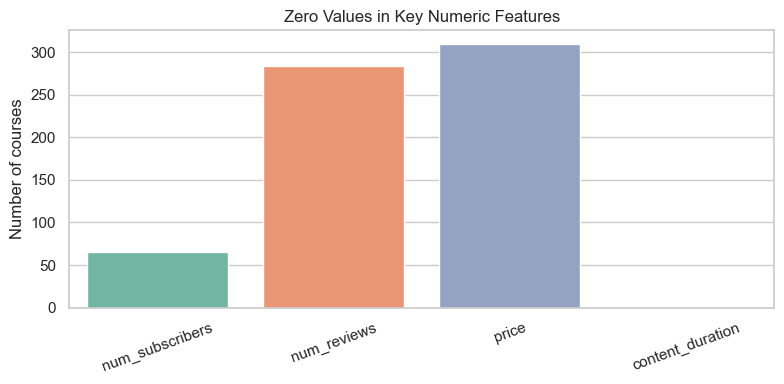

,feature,zero_count
0,num_subscribers,65
1,num_reviews,284
2,price,310
3,content_duration,1


In [12]:
zero_value_summary = pd.DataFrame({
    "feature": ["num_subscribers", "num_reviews", "price", "content_duration"],
    "zero_count": [
        (df["num_subscribers"] == 0).sum(),
        (df["num_reviews"] == 0).sum(),
        (df["price"] == 0).sum(),
        (df["content_duration"] == 0).sum(),
    ],
})

plt.figure(figsize=(8, 4))
sns.barplot(data=zero_value_summary, x="feature", y="zero_count", hue="feature", palette="Set2", legend=False)
plt.title("Zero Values in Key Numeric Features")
plt.xlabel("")
plt.ylabel("Number of courses")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

zero_value_summary


The zero-value check gives useful context for later modeling. There are free courses in the dataset, which is expected because Udemy includes both free and paid courses. Courses with zero reviews or zero subscribers may represent new or less visible courses, so removing them would be too aggressive for this stage.

The single zero-duration record identified during data understanding has been inspected and retained because it affects only one course. Removing it is deferred unless it negatively affects later modeling results.


## 13. Outlier Inspection

Outliers are checked but not removed. In an online course marketplace, very popular courses or long courses can be real and important. For this reason, this notebook only identifies unusual values and leaves the decision to the modeling stage.


In [13]:
outlier_rows = []
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_rows.append({
        "feature": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": count,
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,num_subscribers,111.75,2548.75,2437.0,-3543.75,6204.25,432
1,num_reviews,4.00,67.00,63.0,-90.50,161.50,493
2,price,20.00,95.00,75.0,-92.50,207.50,0
3,content_duration,1.00,4.50,3.5,-4.25,9.75,313


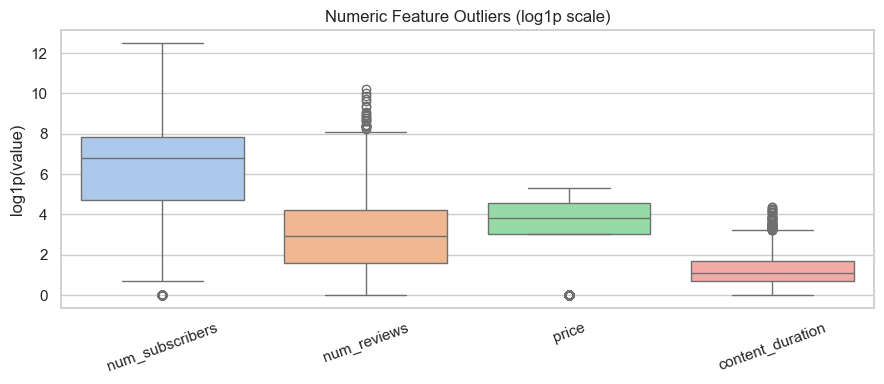

In [14]:
numeric_plot_data = df[numeric_columns].copy()
log_numeric_plot_data = np.log1p(numeric_plot_data)
log_numeric_plot_data = log_numeric_plot_data.melt(var_name="feature", value_name="log_value")

plt.figure(figsize=(9, 4))
sns.boxplot(data=log_numeric_plot_data, x="feature", y="log_value", hue="feature", palette="pastel", legend=False)
plt.title("Numeric Feature Outliers (log1p scale)")
plt.xlabel("")
plt.ylabel("log1p(value)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [15]:
top_courses_by_popularity = df.sort_values("num_subscribers", ascending=False)[[
    "course_id", "course_title", "subject", "level", "num_subscribers", "num_reviews", "price", "content_duration"
]].head(10)

top_courses_by_duration = df.sort_values("content_duration", ascending=False)[[
    "course_id", "course_title", "subject", "level", "num_subscribers", "num_reviews", "price", "content_duration"
]].head(10)

print("Top courses by subscribers:")
display(top_courses_by_popularity)

print("Top courses by content duration:")
display(top_courses_by_duration)


Top courses by subscribers:


,course_id,course_title,subject,level,num_subscribers,num_reviews,price,content_duration
2827,41295,learn html5 programming from scratch,web development,all levels,268923,8629,0,10.5
3032,59014,coding for entrepreneurs basic,web development,beginner level,161029,279,0,3.5
3230,625204,the web developer bootcamp,web development,all levels,121584,27445,200,43.0
2783,173548,build your first website in 1 week with html5 ...,web development,beginner level,120291,5924,0,3.0
3232,764164,the complete web developer course 2.0,web development,all levels,114512,22412,200,30.5
1896,19421,free beginner electric guitar lessons,musical instruments,beginner level,101154,1042,0,4.5
2589,473160,web design for web developers build beautiful ...,web development,all levels,98867,6512,0,3.0
2619,94430,learn javascript jquery from scratch,web development,all levels,84897,2685,30,2.0
3289,130064,practical php master the basics and code dynam...,web development,all levels,83737,4598,0,6.5
3247,364426,javascript understanding the weird parts,web development,all levels,79612,16976,175,11.5


Top courses by content duration:


,course_id,course_title,subject,level,num_subscribers,num_reviews,price,content_duration
1658,978576,the complete figure drawing course hd,graphic design,beginner level,1323,136,50,78.5
3141,548278,the complete web development course build 15 p...,web development,all levels,7501,1213,200,76.5
561,375594,financial management a complete study,business finance,all levels,1941,128,190,71.5
874,167316,trader bot introdução à linguagem mql5,business finance,all levels,209,33,20,70.0
1214,62721,anatomy for figure drawing mastering the human...,graphic design,all levels,15500,754,95,68.5
3611,1008246,modern e commerce store in php mysqli with boo...,web development,all levels,240,45,50,66.5
1202,28556,discover how to draw and paint comics,graphic design,all levels,8901,424,65,62.0
114,866584,advanced accounting a complete study for ca cm...,business finance,all levels,1535,16,150,62.0
2613,140238,become a professional web developer version 3.0,web development,all levels,6851,276,200,60.0
3004,481696,code grow rich earn more as an entrepreneur or...,web development,all levels,7211,52,200,57.0


The numeric features contain outliers, especially in subscribers and reviews. This is expected because online platforms often have a small number of very popular courses. These records should stay in the dataset for now. This preprocessing step prepares the raw features needed for KNN, while vectorization, encoding, and scaling should be performed later inside the KNN notebook so large values do not dominate distance calculations.


## 14. Save Processed Dataset

The final processed dataset is saved in `data/processed/processed_udemy_courses.csv`. Temporary analysis columns such as word counts are not saved, because the next notebooks only need the cleaned recommendation features and `combined_features`.


In [16]:
processed_columns = [
    "course_id",
    "course_title",
    "subject",
    "level",
    "num_subscribers",
    "num_reviews",
    "price",
    "content_duration",
    "combined_features",
]

processed_df = df[processed_columns].copy()

processed_data_path = Path("data/processed/processed_udemy_courses.csv")
if not processed_data_path.parent.exists():
    processed_data_path = Path("../data/processed/processed_udemy_courses.csv")

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
processed_df.to_csv(processed_data_path, index=False)

print(f"Processed dataset saved to: {processed_data_path}")
print(f"Final shape: {processed_df.shape}")


Processed dataset saved to: ..\data\processed\processed_udemy_courses.csv
Final shape: (3672, 9)


The processed file now contains the cleaned text and raw numeric features needed by the TF-IDF and KNN recommender notebooks. Saving it once here keeps the next notebooks cleaner and easier to compare; KNN-specific vectorization, encoding, and scaling will be handled later in the KNN notebook.


## 15. Final Preview

The final preview confirms that the processed dataset contains the selected recommendation fields plus the new `combined_features` column.


In [17]:
processed_df.head()


,course_id,course_title,subject,level,num_subscribers,num_reviews,price,content_duration,combined_features
0,1070968,ultimate investment banking course,business finance,all levels,2147,23,200,1.5,ultimate investment banking course business fi...
1,1113822,complete gst course certification grow your ca...,business finance,all levels,2792,923,75,39.0,complete gst course certification grow your ca...
2,1006314,financial modeling for business analysts and c...,business finance,intermediate level,2174,74,45,2.5,financial modeling for business analysts and c...
3,1210588,beginner to pro financial analysis in excel 2017,business finance,all levels,2451,11,95,3.0,beginner to pro financial analysis in excel 20...
4,1011058,how to maximize your profits trading options,business finance,intermediate level,1276,45,200,2.0,how to maximize your profits trading options b...


The final dataset has one row per course and includes the cleaned text representation needed for TF-IDF similarity-based recommendation, along with raw features that can be transformed later for KNN. This makes `02_preprocessing.ipynb` the shared data preparation step for the next modeling notebooks.
